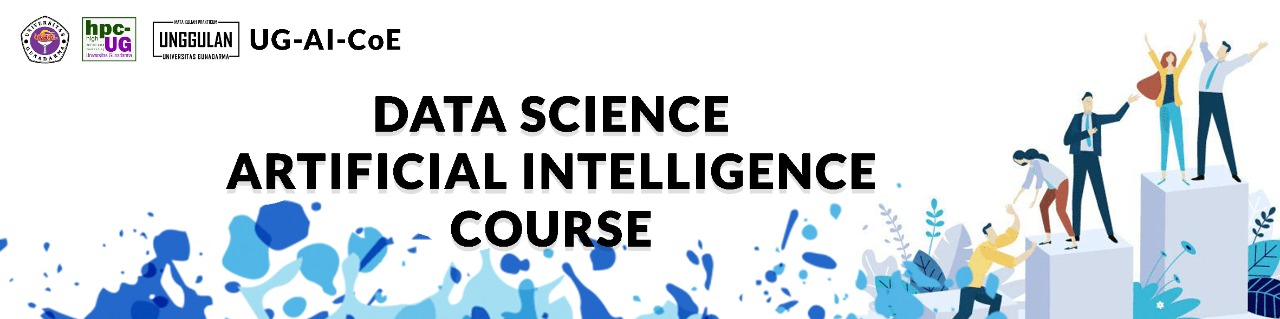

### Nama: Muhammad Ilham Fadly
### NPM : 50423938

# Segmentasi Engagement Facebook Live Sellers (Thailand) — Analisis Clustering

**Dataset:** [Facebook Live Sellers in Thailand, UCI ML Repo (Kaggle)](https://www.kaggle.com/datasets/ashishg21/facebook-live-sellers-in-thailand-uci-ml-repo/data)


**Tahapan CRISP-DM:**
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Kesimpulan


Dataset ini dipilih karena masalah yang ingin dijawab, yaitu "jenis konten seperti apa yang paling efektif menghasilkan engagement, dan apakah ada pola perilaku audiens yang berbeda-beda terhadap suatu postingan?". Secara alami tidak memiliki jawaban benar/salah yang bisa dipelajari dari label historis, karena tidak ada satu pun "kategori performa konten" yang sudah didefinisikan sebelumnya oleh pemilik bisnis, yang tersedia hanyalah jejak interaksi (reaksi, komentar, share) yang polanya justru harus ditemukan, bukan diprediksi dan inilah persis alasan clustering menjadi pendekatan yang tepat, bukan klasifikasi atau regresi.

Dataset ini juga menangkap fenomena bisnis yang secara intuitif memang berbeda, sebuah postingan bisa viral karena disukai banyak orang, viral karena memicu perdebatan di kolom komentar, atau justru sepi tanpa keduanya. Tiga skenario yang secara bisnis butuh strategi penanganan yang sama sekali berbeda, namun tidak mungkin dibedakan hanya dengan melihat rata-rata atau total engagement. Clustering mampu memisahkan skenario-skenario tersembunyi ini menjadi segmen yang dapat ditindaklanjuti. Ditambah lagi, tersedianya status_type sebagai variabel yang sengaja tidak dilibatkan saat pembentukan cluster memberi cara pengujian yang jarang ditemukan di dataset unsupervised.

## **1. Business Understanding**

### 1.1 Latar Belakang
Dataset ini berisi rekam jejak **engagement** (reaksi, komentar, share, like, love, wow, haha, sad, angry) dari postingan-postingan yang dibuat oleh sejumlah *live sellers* (penjual yang berjualan melalui Facebook Live) di Thailand, mencakup 4 jenis konten: `video`, `photo`, `status`, dan `link`.

Bagi pelaku bisnis *social commerce*, memahami postingan mana yang menghasilkan engagement tinggi dan dalam bentuk apa (like biasa, komentar aktif, atau viral), sangat penting untuk merancang strategi konten dan jadwal live selling.

### 1.2 Rumusan Masalah
1. Apakah terdapat pola/segmen alami dari postingan berdasarkan karakteristik engagement-nya?
2. Segmen mana yang mencerminkan "konten viral", "konten dengan diskusi tinggi", atau "konten dengan engagement rendah"?
3. Apakah tipe konten (`status_type`) tertentu cenderung berada pada segmen tertentu?

### 1.3 Tujuan Proyek
Melakukan **segmentasi (clustering)** terhadap postingan berdasarkan pola engagement-nya (tanpa label), agar tim marketing dapat:
- Mengidentifikasi jenis konten dengan performa terbaik.
- Menyusun strategi konten berdasarkan karakteristik tiap segmen.
- Mendeteksi konten yang berpotensi viral atau kontroversial (banyak komentar/reaksi negatif).

### 1.4 Kriteria Keberhasilan
- Diperoleh sejumlah cluster yang **terpisah dengan baik** (dievaluasi dengan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index).
- Setiap cluster dapat **diinterpretasikan secara bisnis** (memiliki karakteristik/persona yang jelas dan actionable).

### 1.5 Pendekatan Data Mining
Karena tidak ada label target (bukan supervised learning), proyek ini menggunakan pendekatan **clustering**, khususnya **K-Means** untuk mengelompokkan postingan berdasarkan kemiripan pola engagement-nya.


## **2. Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_samples

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install -q scikit-learn==1.9.1

**Penjelasan Singkat**
- **Import library**, pandas/numpy untuk olah data, matplotlib/seaborn untuk visualisasi, dan dari sklearn: StandardScaler (standardisasi fitur), KMeans (algoritma clustering), serta 4 metrik (silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples) untuk evaluasi hasil clustering nanti.
- **Konfigurasi tampilan**, atur tema grafik (whitegrid), ukuran default grafik (8x5), dan supaya pandas menampilkan semua kolom tanpa terpotong.
- **RANDOM_STATE = 42**, angka acak tetap (seed) supaya hasil clustering konsisten/reproducible setiap notebook dijalankan ulang.
- **warnings.filterwarnings("ignore")**, menyembunyikan pesan warning (misal dari sklearn/pandas) agar output notebook lebih bersih dan tidak mengganggu pembacaan hasil, meski secara teknis tidak memengaruhi jalannya kode.

### 2.1 Memuat Dataset


In [3]:
df = pd.read_csv('Live.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


### 2.2 Mengecek Dimensi Dataset

In [4]:
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])

Jumlah data: 7050
Jumlah fitur: 16


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

**Analisis Singkat**

- **Ukuran data**: 7.050 baris, 16 kolom.
- **Tidak ada missing value pada 12 kolom utama** (status_id hingga num_angrys) semuanya "7050 non-null", artinya data inti sudah lengkap tanpa perlu imputasi.
- **4 kolom kosong total**: Column1-Column4 semuanya "0 non-null" (100% missing) dan bertipe float64, ini jelas kolom sampah/artefak ekspor data yang tidak punya informasi apa pun, sehingga wajib dibuang di tahap Data Preparation.


### 2.3 Statistik Deskriptif

In [6]:
df.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


### 2.4 Pengecekan Missing Value & Duplikat

In [7]:
print("Jumlah missing value per kolom:")
print(df.isna().sum())
print()
print("Jumlah baris duplikat:", df.duplicated().sum())


Jumlah missing value per kolom:
status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

Jumlah baris duplikat: 51


**Analisis Singkat:**

Kolom `Column1`–`Column4` seluruhnya kosong (100% missing), ini adalah artefak ekspor data dan tidak memiliki informasi, sehingga akan dibuang pada tahap *Data Preparation*. Terdapat juga sejumlah baris duplikat yang perlu dibersihkan.

### 2.5 Distribusi Tipe Postingan (`status_type`)

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


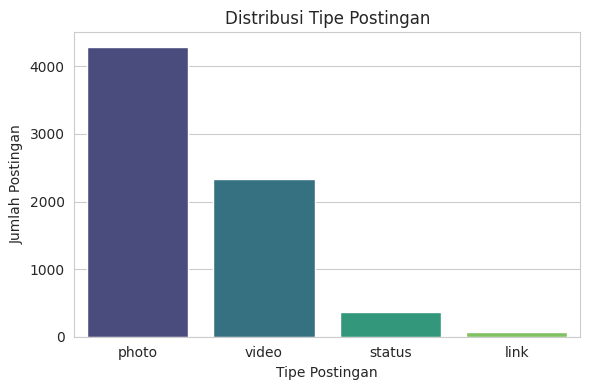

In [8]:
status_counts = df['status_type'].value_counts()
print(status_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index, palette="viridis", legend=False)
plt.title("Distribusi Tipe Postingan")
plt.ylabel("Jumlah Postingan")
plt.xlabel("Tipe Postingan")
plt.tight_layout()
plt.show()


**Analisis Singkat**

Mayoritas postingan berupa `photo`, diikuti `video`, lalu `status` dan `link` dalam jumlah kecil.

### 2.6 Distribusi Fitur Engagement


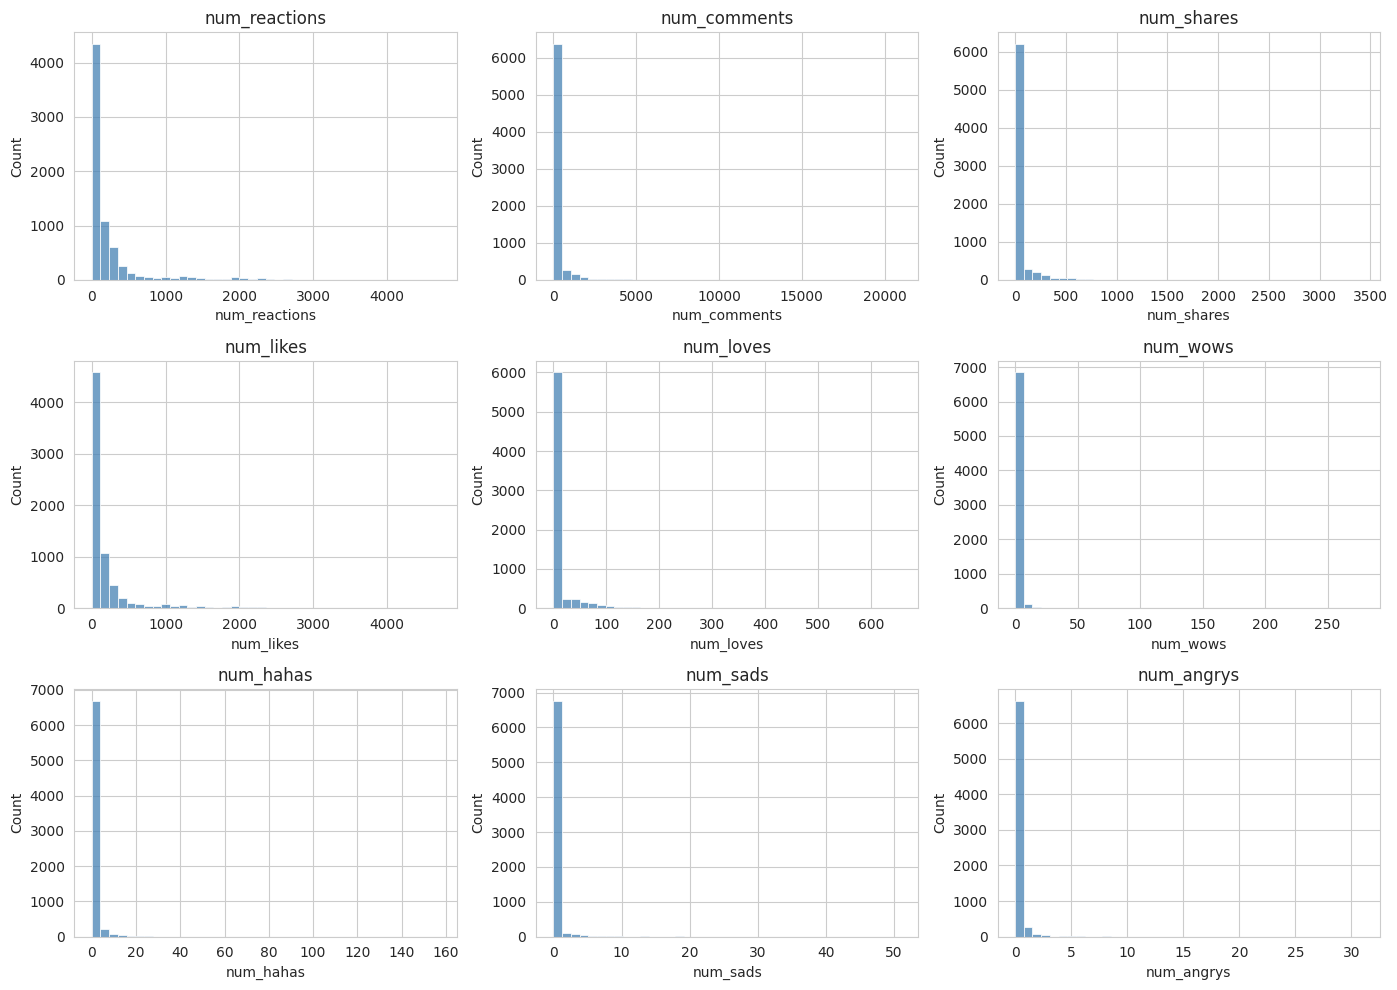

In [9]:
engagement_features = ['num_reactions','num_comments','num_shares','num_likes',
                       'num_loves','num_wows','num_hahas','num_sads','num_angrys']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), engagement_features):
    sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Analisis Singkat**

Seluruh fitur engagement sangat **skewed ke kanan (right-skewed)** dengan banyak outlier bernilai ekstrem. Ini wajar untuk data media sosial, sebagian kecil konten viral mendominasi. Kondisi ini penting diperhatikan pada tahap *Data Preparation* karena algoritma K-Means berbasis jarak Euclidean sangat sensitif terhadap skala dan outlier ekstrem.

### 2.7 Korelasi Antar Fitur Engagement

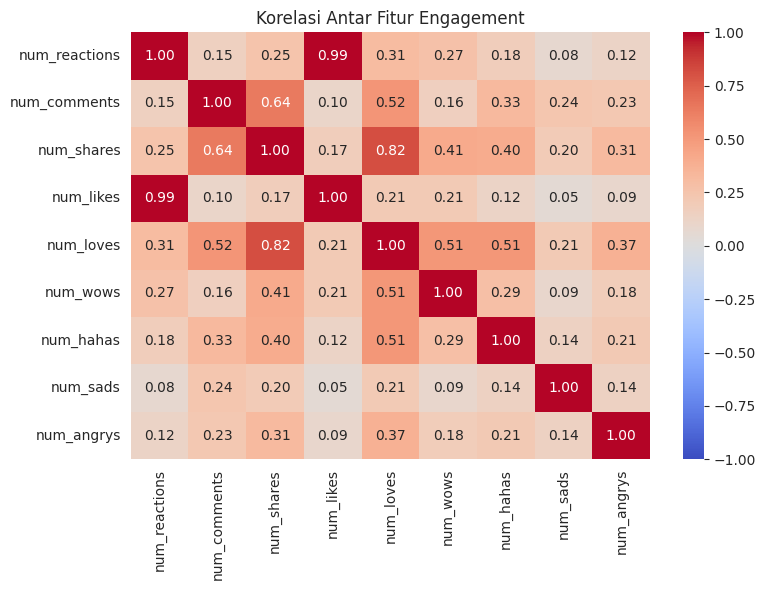

In [10]:
plt.figure(figsize=(8,6))
corr = df[engagement_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Antar Fitur Engagement")
plt.tight_layout()
plt.show()


**Analisis Singkat**

`num_reactions` berkorelasi sangat tinggi dengan `num_likes` (karena like adalah bagian terbesar dari reaksi), sementara `num_comments` cenderung berkorelasi lebih rendah dengan reaksi lain — mengindikasikan bahwa "banyak disukai" dan "banyak dikomentari/diperdebatkan" adalah dua dimensi engagement yang berbeda.

## **3. Data Preparation**

### 3.1 Membuang Kolom Kosong dan Baris Duplikat

In [11]:
df_clean = df.drop(columns=['Column1','Column2','Column3','Column4'])
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Ukuran data setelah pembersihan:", df_clean.shape)


Ukuran data setelah pembersihan: (6999, 12)


### 3.2 Feature Engineering — Ekstraksi Waktu Publikasi
Kolom `status_published` diubah menjadi fitur `hour` (jam publikasi) dan `day_of_week` (hari dalam seminggu) yang berpotensi berguna untuk analisis lanjutan, meskipun untuk clustering utama kita akan berfokus pada fitur engagement.

In [12]:
df_clean['status_published'] = pd.to_datetime(df_clean['status_published'], format='%m/%d/%Y %H:%M')
df_clean['hour'] = df_clean['status_published'].dt.hour
df_clean['day_of_week'] = df_clean['status_published'].dt.day_name()
df_clean[['status_published','hour','day_of_week']].head()


,status_published,hour,day_of_week
0,2018-04-22 06:00:00,6,Sunday
1,2018-04-21 22:45:00,22,Saturday
2,2018-04-21 06:17:00,6,Saturday
3,2018-04-21 02:29:00,2,Saturday
4,2018-04-18 03:22:00,3,Wednesday


### 3.3 Pemilihan Fitur untuk Clustering
Kolom `status_id` (ID unik) dan `status_published` (timestamp) tidak relevan sebagai fitur jarak untuk clustering.

Dari 9 fitur engagement yang ada, perlu dicatat bahwa **6 fitur rincian reaksi** (`num_likes, num_loves, num_wows, num_hahas, num_sads, num_angrys`) sebenarnya adalah **komponen penyusun `num_reactions`** itu sendiri, sehingga jumlah keenamnya kurang lebih sama dengan `num_reactions` (redundan/multikolinearitas tinggi). Mari kita buktikan secara numerik.

In [13]:
check = df_clean[['num_reactions']].copy()
check['sum_breakdown'] = df_clean[['num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']].sum(axis=1)
check['selisih'] = check['num_reactions'] - check['sum_breakdown']
check.describe()


,num_reactions,sum_breakdown,selisih
count,6999.000000,6999.000000,6999.000000
mean,224.994571,224.991856,0.002715
std,452.880746,452.879431,0.083634
min,0.000000,0.000000,0.000000
25%,17.000000,17.000000,0.000000
50%,58.000000,58.000000,0.000000
75%,216.000000,216.000000,0.000000
max,4710.000000,4710.000000,4.000000


**Analisis Singkat**

`num_reactions` hampir identik dengan jumlah keenam rincian reaksinya (selisih median ≈ 0). Karena itu, kita **menyederhanakan fitur clustering menjadi 3 fitur inti** yang paling merepresentasikan dimensi engagement secara independen dan tidak saling redundan:

| Fitur | Merepresentasikan |
|---|---|
| `num_reactions` | Seberapa **disukai** suatu konten (total reaksi apapun jenisnya) |
| `num_comments` | Seberapa **didiskusikan** suatu konten |
| `num_shares` | Seberapa **disebarluaskan** suatu konten |

Pendekatan 3 fitur ini juga memudahkan interpretasi dan visualisasi (dapat digambarkan langsung dalam ruang 3 dimensi tanpa reduksi PCA), serta terbukti  menghasilkan cluster yang lebih seimbang (dibahas pada tahap Evaluation).

In [14]:
cluster_features = ['num_reactions', 'num_comments', 'num_shares']
X = df_clean[cluster_features].copy()
X.head()


,num_reactions,num_comments,num_shares
0,529,512,262
1,150,0,0
2,227,236,57
3,111,0,0
4,213,0,0


### 3.4 Penanganan Skewness & Outlier
Seperti terlihat pada tahap *Data Understanding*, seluruh fitur sangat skewed. Tanpa penanganan, K-Means akan didominasi oleh segelintir outlier ekstrem (menghasilkan cluster yang tidak seimbang dan sulit diinterpretasikan). Kita terapkan **transformasi log(1+x)** untuk mengurangi pengaruh outlier dan membuat distribusi lebih mendekati normal, sebelum melakukan standardisasi.

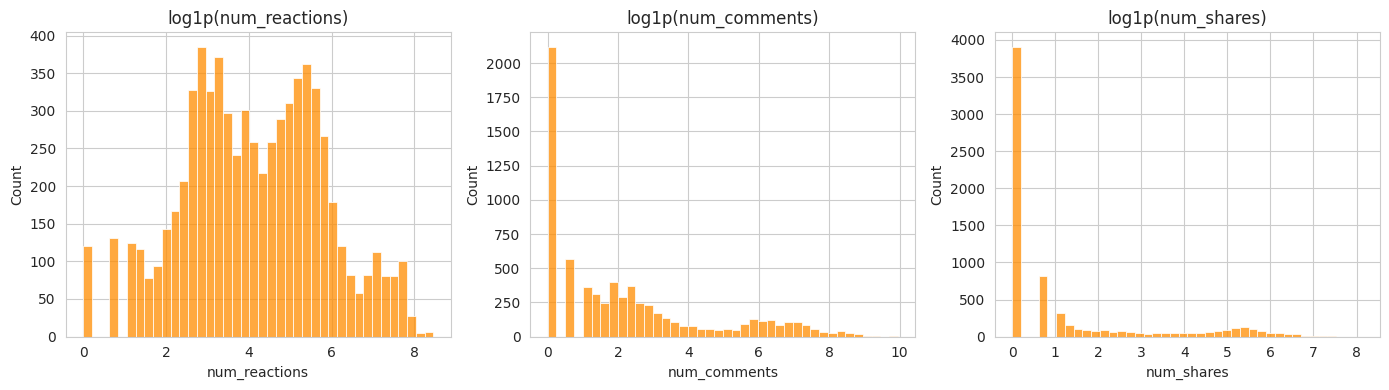

In [15]:
X_log = np.log1p(X)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes.flatten(), cluster_features):
    sns.histplot(X_log[col], bins=40, ax=ax, color="darkorange")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()


**Penjelasan Singkat**

Setelah transformasi log, distribusi fitur menjadi jauh lebih landai dan lebih sesuai untuk perhitungan jarak Euclidean pada K-Means.

### 3.5 Standardisasi Fitur (Feature Scaling)
Karena K-Means berbasis jarak, seluruh fitur perlu berada pada skala yang sama. Kita gunakan `StandardScaler` (mean = 0, std = 1).

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled.describe().round(2)


,num_reactions,num_comments,num_shares
count,6999.00,6999.00,6999.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.39,-0.95,-0.64
25%,-0.71,-0.95,-0.64
50%,-0.02,-0.26,-0.64
75%,0.74,0.39,0.21
max,2.53,3.31,3.67


## **4. Modeling**

### 4.1 Menentukan Jumlah Cluster Optimal — Elbow Method
Kita jalankan K-Means untuk berbagai nilai K (2 hingga 9) dan amati **inertia** untuk mencari "siku" (elbow) di mana penambahan cluster tidak lagi signifikan menurunkan inertia.

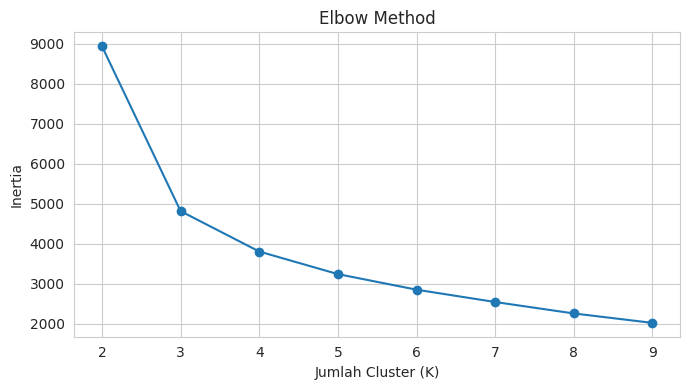

In [17]:
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


### 4.2 Validasi dengan Silhouette Score
Elbow method bersifat visual dan kadang ambigu, sehingga kita perkuat dengan **Silhouette Score** (semakin mendekati 1, semakin baik pemisahan antar cluster).

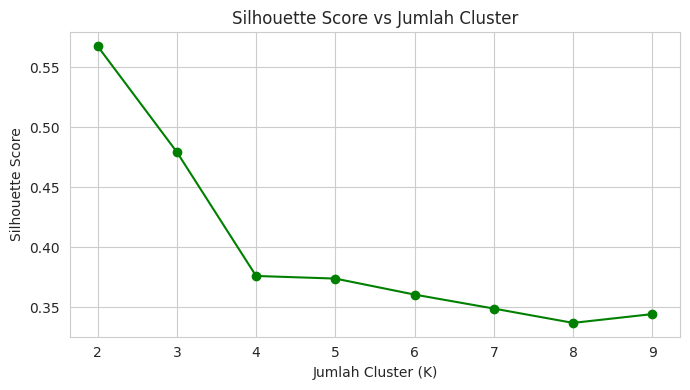

K=2: silhouette=0.5677
K=3: silhouette=0.4794
K=4: silhouette=0.3760
K=5: silhouette=0.3739
K=6: silhouette=0.3605
K=7: silhouette=0.3489
K=8: silhouette=0.3369
K=9: silhouette=0.3442


In [18]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(K_range), sil_scores, marker='o', color='green')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Jumlah Cluster")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"K={k}: silhouette={s:.4f}")


**Keputusan Pemilihan K:**

Silhouette score menurun secara konsisten seiring bertambahnya jumlah cluster, dari 0.568 pada K=2 hingga sekitar 0.34 pada K=8-9, sehingga secara statistik murni K=2 memberikan pemisahan cluster yang paling rapat. Namun, **nilai tertinggi ini justru mengindikasikan bahwa algoritma menggabungkan dua perilaku audiens yang secara bisnis berbeda postingan yang disukai secara pasif dan postingan yang memicu diskusi aktif ke dalam satu cluster besar yang sama**, sehingga kurang informatif untuk kebutuhan segmentasi konten.

Pada **K=3, silhouette score (0.479)** masih tergolong tinggi dan jauh lebih baik dibanding **K=4 ke atas (0.376 dan seterusnya)**, sementara pemeriksaan awal terhadap isi cluster menunjukkan bahwa pada titik ini pola "reaksi tinggi" dan "komentar tinggi" sudah mulai terpisah secara jelas menjadi segmen tersendiri. Oleh karena itu, K=3 dipilih sebagai kandidat jumlah cluster yang akan digunakan, dengan pertimbangan bahwa penurunan silhouette dari K=2 ke K=3 masih relatif moderat, sementara segmentasi yang dihasilkan sudah cukup bermakna secara bisnis dibanding hanya menggunakan dua kelompok besar. Kelayakan pilihan ini akan diperkuat lebih lanjut melalui metrik evaluasi tambahan (Davies-Bouldin Index dan Calinski-Harabasz Index) pada tahap Evaluation.

### 4.3 Melatih Model K-Means Final (K=3)

In [19]:
K_FINAL = 3
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Distribusi jumlah anggota tiap cluster:")
print(df_clean['cluster'].value_counts().sort_index())

Distribusi jumlah anggota tiap cluster:
cluster
0    3518
1    1172
2    2309
Name: count, dtype: int64


### 4.4 Visualisasi Cluster
Karena hanya menggunakan **3 fitur**, cluster dapat divisualisasikan langsung dalam ruang 3 dimensi tanpa perlu reduksi dimensi (PCA), sehingga tidak ada informasi yang hilang saat divisualisasikan.

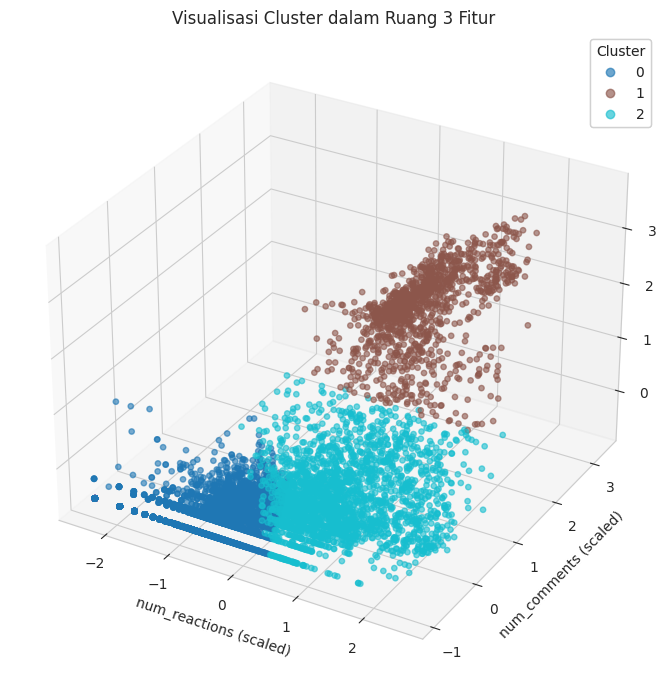

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_scaled['num_reactions'], X_scaled['num_comments'], X_scaled['num_shares'],
                 c=df_clean['cluster'], cmap='tab10', alpha=0.6, s=15)
ax.set_xlabel('num_reactions (scaled)')
ax.set_ylabel('num_comments (scaled)')
ax.set_zlabel('num_shares (scaled)')
ax.set_title('Visualisasi Cluster dalam Ruang 3 Fitur')
legend = ax.legend(*sc.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

Sebagai pelengkap, berikut visualisasi 2D untuk tiap pasangan fitur agar pemisahan antar cluster lebih mudah diamati dari berbagai sudut.

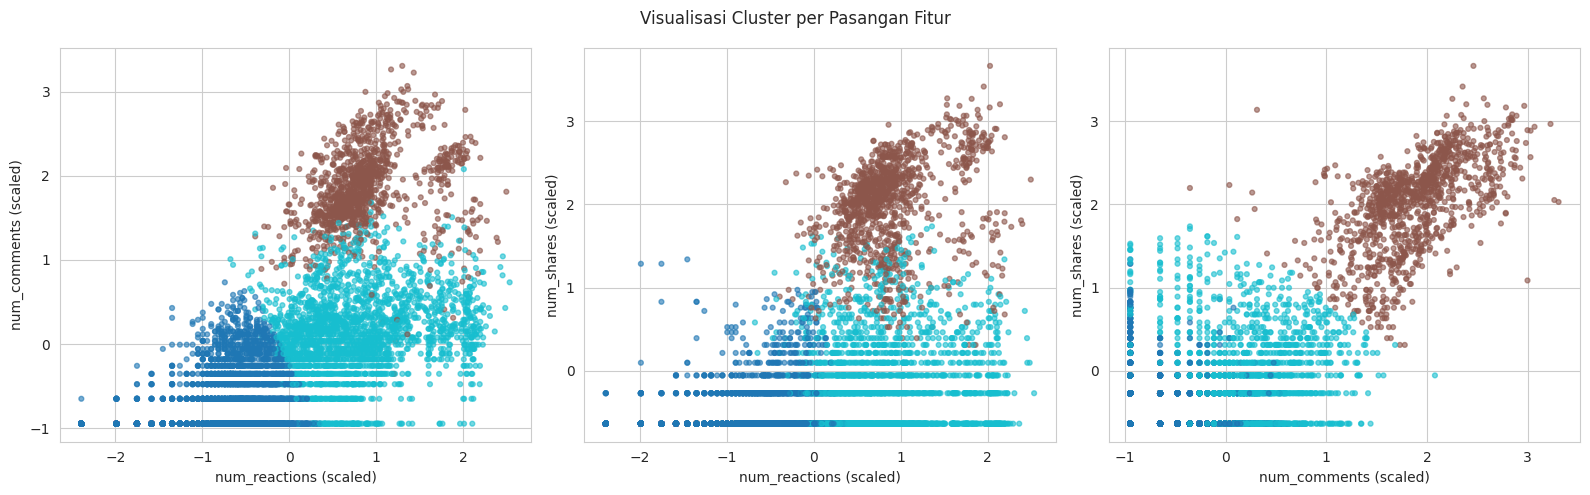

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
pairs = [('num_reactions','num_comments'), ('num_reactions','num_shares'), ('num_comments','num_shares')]
for ax, (fx, fy) in zip(axes, pairs):
    sc = ax.scatter(X_scaled[fx], X_scaled[fy], c=df_clean['cluster'], cmap='tab10', alpha=0.6, s=12)
    ax.set_xlabel(f"{fx} (scaled)")
    ax.set_ylabel(f"{fy} (scaled)")
plt.suptitle("Visualisasi Cluster per Pasangan Fitur")
plt.tight_layout()
plt.show()

**Analisis Singkat**

- **Cluster cokelat (viral & banyak diperdebatkan)** konsisten terpisah jelas dari dua cluster lain di ketiga panel postingan ini punya `num_comments` dan `num_shares` yang sama-sama tinggi, bahkan membentuk pola diagonal rapi di panel kanan (num_comments vs num_shares), menandakan komentar dan share saling berkorelasi kuat sebagai indikator keterlibatan aktif.
- **Cluster cyan (populer tapi pasif) vs biru tua (engagement rendah)** hanya terpisah jelas saat melibatkan `num_reactions` (panel kiri & tengah). cyan menyebar ke nilai reaksi lebih tinggi, biru tua menumpuk di reaksi rendah tapi keduanya menyatu/tumpang tindih di panel kanan karena sama-sama rendah pada `num_comments` dan `num_shares`.
- **Kesimpulan:** `num_reactions` adalah fitur pembeda utama antara "populer pasif" vs "engagement rendah", sedangkan `num_comments` dan `num_shares` adalah fitur pembeda utama antara "viral/diskusi aktif" vs dua cluster lainnya, mengonfirmasi bahwa ketiga fitur yang dipilih memang saling melengkapi, tidak redundan.

## 5. Evaluation

### 5.1 Metrik Evaluasi Kuantitatif
Kita evaluasi hasil clustering final menggunakan tiga metrik *internal validation* (karena tidak ada label ground-truth):

- **Silhouette Score** (rentang -1 s.d. 1, makin tinggi makin baik): mengukur seberapa mirip suatu titik dengan cluster-nya sendiri dibanding cluster terdekat lainnya.
- **Davies-Bouldin Index** (makin rendah makin baik): mengukur rasio jarak dalam-cluster terhadap jarak antar-cluster.
- **Calinski-Harabasz Index** (makin tinggi makin baik): rasio antara variansi antar-cluster dan variansi dalam-cluster.

In [22]:
sil = silhouette_score(X_scaled, df_clean['cluster'])
db = davies_bouldin_score(X_scaled, df_clean['cluster'])
ch = calinski_harabasz_score(X_scaled, df_clean['cluster'])

print(f"Silhouette Score      : {sil:.4f}")
print(f"Davies-Bouldin Index  : {db:.4f}")
print(f"Calinski-Harabasz Idx : {ch:.2f}")

Silhouette Score      : 0.4794
Davies-Bouldin Index  : 0.7491
Calinski-Harabasz Idx : 11749.56


**Penjelasan Singkat**

- **Silhouette Score = 0.4794**, mengukur seberapa baik titik data cocok dengan cluster-nya sendiri (rentang -1 s.d. 1, makin tinggi makin baik). Nilai ini tergolong cukup baik, menandakan pemisahan cluster sudah cukup jelas meski ada sedikit titik di area perbatasan antar cluster.
- **Davies-Bouldin Index = 0.7491**, mengukur rasio jarak dalam-cluster vs antar-cluster (makin rendah makin baik). Nilai ini tergolong baik, menunjukkan cluster cukup rapat dan tidak banyak tumpang tindih.
- **Calinski-Harabasz Index = 11.749,56**, mengukur rasio variansi antar-cluster vs dalam-cluster (makin tinggi makin baik, dibandingkan relatif antar K). Nilai ini tertinggi dibanding semua K yang diuji, menandakan K=3 memberi pemisahan cluster paling optimal.

### 5.2 Silhouette Plot per Cluster
Visualisasi ini menunjukkan konsistensi tiap cluster secara lebih rinci, cluster yang baik memiliki mayoritas anggota dengan silhouette value di atas rata-rata keseluruhan (garis putus-putus merah).

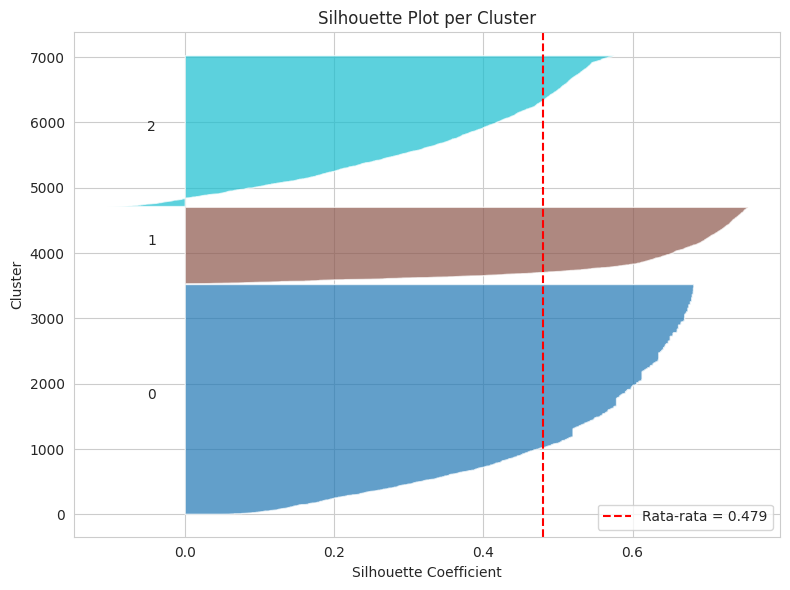

In [23]:
sample_sil_values = silhouette_samples(X_scaled, df_clean['cluster'])

fig, ax = plt.subplots(figsize=(8,6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, K_FINAL))
for i in range(K_FINAL):
    ith_cluster_values = sample_sil_values[df_clean['cluster'] == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--", label=f"Rata-rata = {sil:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot per Cluster")
ax.legend()
plt.tight_layout()
plt.show()

**Cara membaca:**

Sumbu Y menunjukkan cluster (0, 1, 2) beserta anggotanya, disusun dari nilai silhouette terendah ke tertinggi di dalam tiap cluster.
Sumbu X menunjukkan nilai silhouette coefficient tiap titik data (rentang -1 s.d. 1).
Lebar vertikal tiap blok = jumlah anggota cluster tersebut.
Garis merah putus-putus = rata-rata silhouette keseluruhan (0.479).

**Analisis tiap cluster:**

- **Cluster 0 (biru, ~3.500 postingan)**, cluster terbesar (ini adalah segmen "engagement rendah"). Mayoritas batangnya berada di atas garis rata-rata, bahkan banyak yang mencapai 0.6–0.7, menandakan cluster ini paling solid dan konsisten, wajar karena postingan dengan engagement rendah punya karakteristik yang sangat seragam (kebanyakan nilainya mendekati nol).
- **Cluster 1 (cokelat, ~1.170 postingan)**, cluster terkecil (segmen "viral & banyak diperdebatkan"). Ini yang paling lemah: mayoritas batangnya berada di bawah garis rata-rata, berkisar 0.2–0.4. Artinya titik-titik di cluster ini lebih "ambigu", cukup mirip dengan cluster tetangganya, masuk akal karena postingan viral sering berada di zona transisi (kombinasi reaksi & komentar yang bervariasi, tidak seseragam cluster low-engagement).
- **Cluster 2 (cyan, ~2.300 postingan)**, segmen "populer tapi pasif". Sebagian besar juga di atas rata-rata (0.3–0.6), meski ada sedikit bagian tipis mendekati nol di ujung bawah, menandakan ada sejumlah kecil titik yang berada di perbatasan dengan cluster lain.

### 5.3 Profil Karakteristik Tiap Cluster
Kita hitung rata-rata nilai **3 fitur clustering** (skala asli, bukan hasil log/scaling) pada tiap cluster untuk memahami karakteristik dan memberi "nama" pada tiap segmen.

In [24]:
cluster_profile = df_clean.groupby('cluster')[cluster_features].mean().round(1)
cluster_profile['jumlah_postingan'] = df_clean['cluster'].value_counts().sort_index()
cluster_profile

,num_reactions,num_comments,num_shares,jumlah_postingan
cluster,,,,
0,21.3,1.9,0.5,3518
1,419.4,1298.3,232.2,1172
2,436.6,21.8,3.4,2309


**Analisis Singkat**

- Cluster 0 — "Engagement Rendah" (3.518 postingan, 50% dari total)
Reaksi (21.3), komentar (1.9), dan share (0.5) sama-sama sangat rendah di ketiga fitur. Ini cluster terbesar, menandakan mayoritas postingan tidak berhasil menarik interaksi signifikan dari audiens kandidat utama untuk dievaluasi ulang strategi kontennya.
- Cluster 1 — "Viral & Banyak Diperdebatkan" (1.172 postingan, 17% dari total)
Cluster terkecil tapi paling menonjol di semua fitur: komentar sangat tinggi (1.298, ~684x lipat cluster 0), share tertinggi (232), dan reaksi juga tinggi (419). Ini segmen konten yang berhasil memicu diskusi/reaksi aktif dan tersebar luas layak dijadikan referensi format konten untuk direplikasi.
- Cluster 2 — "Populer tapi Pasif" (2.309 postingan, 33% dari total)
Reaksi paling tinggi dari ketiganya (436.6, sedikit di atas cluster 1), tapi komentar (21.8) dan share (3.4) jauh lebih rendah dibanding cluster 1. Artinya konten ini disukai secara pasif banyak yang like/react, tapi tidak memicu diskusi atau penyebaran lebih lanjut.

### 5.5 Interpretasi Bisnis Tiap Segmen

Berdasarkan profil rata-rata **3 fitur clustering** (`num_reactions`, `num_comments`, `num_shares`) pada tabel `cluster_profile`, ketiga cluster (K=3) dapat diinterpretasikan sebagai berikut:

- **Cluster 1 — "Konten Viral & Banyak Diperdebatkan"** (1.172 postingan, 17%): reaksi tinggi (419.4), komentar sangat tinggi (1.298,3), dan share tertinggi (232.2) di antara ketiga cluster. Cluster terkecil namun paling menonjol interaksinya, layak dijadikan studi kasus untuk direplikasi formatnya, sekaligus dicek konteksnya (apakah diskusi bersifat positif atau kontroversial) melalui breakdown jenis reaksi.
- **Cluster 2 — "Konten Populer namun Pasif"** (2.309 postingan, 33%): reaksi paling tinggi (436.6), tetapi komentar (21.8) dan share (3.4) rendah. Banyak disukai tapi tidak memicu diskusi atau penyebaran lebih lanjut, cocok untuk konten yang sifatnya *showcase produk* singkat.
- **Cluster 0 — "Konten dengan Engagement Rendah"** (3.518 postingan, 50%, jumlah anggota terbesar): ketiga metrik sama-sama sangat rendah (reaksi 21.3, komentar 1.9, share 0.5). Kandidat utama untuk dievaluasi ulang strategi kontennya atau dikurangi frekuensinya.

### 5.6 Kelebihan dan Keterbatasan Model
**Kelebihan:**
- K-Means sederhana dan cepat, hasil evaluasi (Silhouette 0.479, Davies-Bouldin 0.749, Calinski-Harabasz tertinggi di antara seluruh K yang diuji) menunjukkan pemisahan cluster yang cukup baik dan konsisten.
- Penyederhanaan menjadi **3 fitur inti** (menghindari redundansi dengan 6 fitur rincian reaksi) membuat cluster lebih mudah diinterpretasikan dan divisualisasikan langsung tanpa reduksi dimensi (PCA).
- Transformasi log berhasil mengurangi pengaruh outlier ekstrem sehingga segmentasi lebih seimbang dibanding menggunakan data mentah.

**Keterbatasan:**
- Pemilihan K=3 mempertimbangkan trade-off antara metrik statistik dan interpretabilitas bisnis, sehingga tetap ada unsur judgment, bukan murni hasil optimasi otomatis.
- 6 fitur rincian jenis reaksi (like, love, wow, haha, sad, angry) hanya digunakan sebagai konteks tambahan, belum dimanfaatkan sepenuhnya untuk membedakan sentimen (positif vs negatif) dalam proses clustering utama.
- Fitur waktu (`hour`, `day_of_week`) belum dimasukkan ke dalam proses clustering utama dan dapat dieksplorasi pada iterasi berikutnya.

## 6. Kesimpulan

Proyek clustering ini berhasil mengidentifikasi **3 segmen konten** yang jelas dan bermakna secara bisnis berdasarkan pola engagement-nya, dengan pemisahan yang didukung baik secara kuantitatif (Silhouette Score 0.479, Davies-Bouldin Index 0.749, dan Calinski-Harabasz Index tertinggi di antara seluruh nilai K yang diuji) maupun visual. Ketiga segmen tersebut adalah **"Viral & Banyak Diperdebatkan"** (reaksi, komentar, dan share sama-sama tinggi), **"Populer namun Pasif"** (reaksi tinggi, namun komentar dan share rendah), serta **"Engagement Rendah"** (ketiga metrik rendah, mendominasi separuh dari seluruh postingan). Hasil ini membuktikan bahwa "disukai secara pasif" dan "memicu diskusi aktif" merupakan dua dimensi engagement yang berbeda dan berhasil dipisahkan oleh model, sehingga menjawab rumusan masalah yang ditetapkan pada tahap Business Understanding, bahwa terdapat pola/segmen alami dari postingan yang dapat digunakan untuk menyusun strategi konten yang lebih tepat sasaran, sekaligus menjadi dasar bagi tim bisnis untuk mengevaluasi performa konten dan merancang sistem penilaian segmen secara otomatis di masa mendatang.

### 6.4 Menyimpan Hasil & Artefak Model

In [25]:
import joblib

# Simpan model, scaler, dan daftar fitur untuk dipakai kembali pada data baru
joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(cluster_features, 'cluster_features.pkl')

print("Tersimpan: kmeans_model.pkl, scaler.pkl, cluster_features.pkl")

Tersimpan: kmeans_model.pkl, scaler.pkl, cluster_features.pkl
